# Concatenating, Joining, and Pivoting Data

There are several ways of answering many questions in this notebook, but try to use the new operations (concatenate, joint/merge, pivot) whenever possible to get practice.

In [58]:
import pandas as pd

## Movie Ratings Data

The Movielens data set (https://dlsun.github.io/pods/data/ml-1m/ ) contains 1 million movie ratings submitted by users. The information about the movies, ratings, and users are stored in three separate files, called `movies.dat`, `ratings.dat`, and `users.dat`. The column names are not included with the data files. Refer to the webpage above for more information.


1\. Read in each of the data files.


(Hint: see the note in the documentation about the delimiter; use the `sep` argument in `read_csv`. If you get an error when reading the `movies.dat` file, try `encoding_errors = "ignore"` in `read_csv`.)

In [59]:
# YOUR CODE HERE
base = "https://dlsun.github.io/pods/data/ml-1m/"

movies_url = base + "movies.dat"
ratings_url = base + "ratings.dat"
users_url = base + "users.dat"

movies_df = pd.read_csv(movies_url, sep="::", 
                        encoding_errors="ignore", 
                        header=None, names=["movie_id", "title", "genre"]
                        )

ratings_df = pd.read_csv(ratings_url, sep="::", 
                        encoding_errors="ignore", 
                        header=None, names=["user_id", "movie_id", "rating", "timestamp"]
                        )

users_df = pd.read_csv(users_url, sep="::", 
                        encoding_errors="ignore", 
                        header=None, names=["user_id", "gender", "age", "occupation", "zip"]
                        )
movies_df.head()

<positron-console-cell-59>:8: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
<positron-console-cell-59>:13: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
<positron-console-cell-59>:18: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


,movie_id,title,genre
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [60]:
ratings_df.head()

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [61]:
users_df

,user_id,gender,age,occupation,zip
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455
...,...,...,...,...,...
6035,6036,F,25,15,32603
6036,6037,F,45,1,76006
6037,6038,F,56,1,14706
6038,6039,F,45,0,01060


2\. Which age group tends to give the highest ratings? Create an appropriate summary to answer this question.

(Note the way age is coded in the [REAMDE file](https://dlsun.github.io/pods/data/ml-1m/README.txt).)

In [62]:
users_ratings_df = users_df.merge(ratings_df, on="user_id", how="left")
users_ratings_df.head()

,user_id,gender,age,occupation,zip,movie_id,rating,timestamp
0,1,F,1,10,48067,1193,5,978300760
1,1,F,1,10,48067,661,3,978302109
2,1,F,1,10,48067,914,3,978301968
3,1,F,1,10,48067,3408,4,978300275
4,1,F,1,10,48067,2355,5,978824291


In [63]:
users_ratings_df.groupby("age")["rating"].mean().sort_values(ascending=False)

age
56    3.766632
50    3.714512
45    3.638062
35    3.618162
1     3.549520
25    3.545235
18    3.507573
Name: rating, dtype: float64

56 gives the highest average rating of 3.77

3\. Among movies with at least 100 ratings, which movies had the highest average rating? The lowest?

In [64]:
movies_ratings_df = movies_df.merge(ratings_df, on="movie_id", how="left")

popular_ids = movies_ratings_df["movie_id"].value_counts()
popular_ids = popular_ids[popular_ids > 100].index

filtered_df = movies_ratings_df[movies_ratings_df["movie_id"].isin(popular_ids)]

filtered_df.groupby(["movie_id", "title"])["rating"].mean().sort_values(ascending=False).head()

movie_id  title                                                              
2019      Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954)    4.560510
318       Shawshank Redemption, The (1994)                                       4.554558
858       Godfather, The (1972)                                                  4.524966
745       Close Shave, A (1995)                                                  4.520548
50        Usual Suspects, The (1995)                                             4.517106
Name: rating, dtype: float64

In [65]:
filtered_df.groupby(["movie_id", "title"])["rating"].mean().sort_values(ascending=True).head()

movie_id  title                                    
810       Kazaam (1996)                                1.466667
3593      Battlefield Earth (2000)                     1.611111
2817      Aces: Iron Eagle III (1992)                  1.640000
2383      Police Academy 6: City Under Siege (1989)    1.657718
2555      Baby Geniuses (1999)                         1.701220
Name: rating, dtype: float64

4\. For each movie, calculate the average rating and the proportion of the ratings that were from users aged 18-24. Make a scatterplot showing the relationship between the average rating and the 18-24 share, with each point representing a movie. (Optional: Use the size of each point to represent the number of users who rated the movie.)

In [66]:
# YOUR CODE HERE
movies_ratings_users_df = movies_ratings_df.merge(users_df, on="user_id", how="left")
avg_rating = movies_ratings_users_df.groupby("movie_id")["rating"].mean()
avg_rating.head()

movie_id
1    4.146846
2    3.201141
3    3.016736
4    2.729412
5    3.006757
Name: rating, dtype: float64

In [67]:
is_young = movies_ratings_users_df["age"] == 18
young_share = movies_ratings_users_df.assign(young=is_young).groupby("movie_id")["young"].mean()
young_share.head()

movie_id
1    0.215696
2    0.219686
3    0.223849
4    0.229412
5    0.219595
Name: young, dtype: float64

In [68]:
movie_stats = pd.DataFrame({"avg_rating": avg_rating, "young_share": young_share})
movie_stats.head()

,avg_rating,young_share
movie_id,,
1,4.146846,0.215696
2,3.201141,0.219686
3,3.016736,0.223849
4,2.729412,0.229412
5,3.006757,0.219595


<Axes: xlabel='avg_rating', ylabel='young_share'>

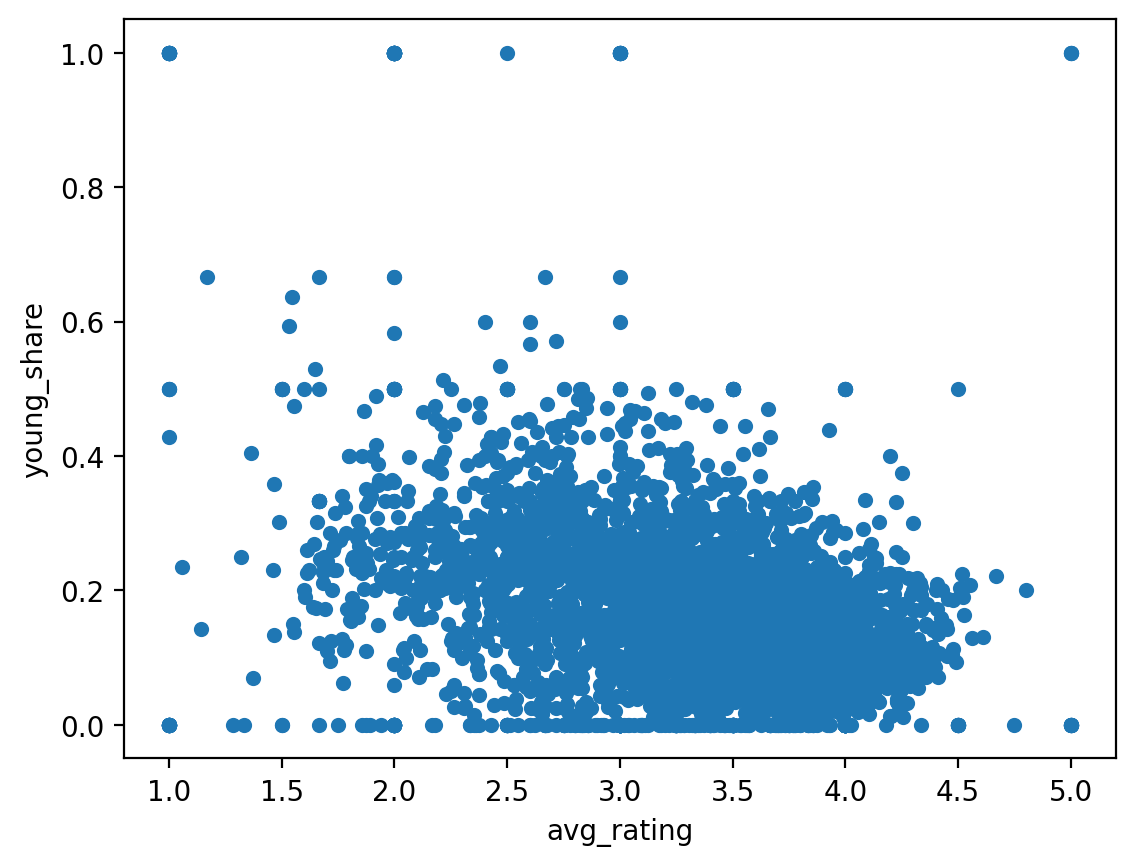

In [69]:
movie_stats.plot.scatter(x="avg_rating", y="young_share")

5\. Calculate the number of ratings by movie. How many of the movies had zero ratings?

(_Hint_: Why is an inner join not sufficient here?)

In [70]:
ratings_count = movies_ratings_df.groupby("movie_id")["rating"].count()
ratings_count.head()

movie_id
1    2077
2     701
3     478
4     170
5     296
Name: rating, dtype: int64

In [71]:
# Num of movies with 0 ratings
(ratings_count == 0).sum()

np.int64(177)

6\. How many movies received both a 1 and a 5 rating? Which movies? How many ratings of each type (1 or 5 stars)? Answer these question by joining two appropriate tables.

In [72]:
ones = movies_ratings_df[movies_ratings_df["rating"] == 1].groupby("movie_id").size()
ones

movie_id
1       16
2       42
3       44
4       21
5       28
        ..
3948    35
3949     9
3950     2
3951     1
3952     9
Length: 3274, dtype: int64

In [73]:
fives = movies_ratings_df[movies_ratings_df["rating"] == 5].groupby("movie_id").size()
fives

movie_id
1       820
2        48
3        43
4         6
5        16
       ... 
3948    163
3949    132
3950     12
3951     14
3952     83
Length: 3232, dtype: int64

In [74]:
ones.to_frame().merge(fives.to_frame(), on="movie_id", how="inner")

,0_x,0_y
movie_id,,
1,16,820
2,42,48
3,44,43
4,21,6
5,28,16
...,...,...
3948,35,163
3949,9,132
3950,2,12
